(02-09-black-scholes)=

# Black-Scholes-Merton en de CBOE

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1961–1973.

**Wat we al weten.** Bachelier leidde in [](#01-02-bachelier) de eerste
optieformule af door een verwachting te nemen. Waarom een verwachting zonder
correctie voor risico de prijs is, kon hij niet zeggen. Het CAPM uit [](#02-08-capm) gaf een prijs van
risico, maar vroeg daarvoor het verwachte rendement, het slechtst meetbare getal
van de reeks.

**Welke vraag staat open.** Kan een optie geprijsd worden zonder te weten welk
rendement het aandeel verwacht en hoe risicoavers beleggers zijn?
```

## Overzicht

Wat is een optie waard als niemand weet welk rendement het aandeel verwacht? Wat
het kost om haar na te maken met aandeel en obligatie. Die kosten hangen van de
volatiliteit af, niet van het verwachte rendement en niet van de risicoaversie.
In deze lecture:

- maken we in een binomiale boom van drie stappen een call na, en zien we dat de
  kans op een stijging nergens in de prijs voorkomt;

- leiden we met Itô's lemma de partiële differentiaalvergelijking af, en daaruit
  de Black-Scholes-formule als verdisconteerde verwachting;

- berekenen we wat een handelaar verdient die met de verkeerde volatiliteit hedget;

- simuleren we hoe groot de spreiding van de P&L (winst of verlies) is als niet continu maar dagelijks,
  wekelijks of maandelijks wordt gehedgd;

- repliceren we de *smirk* van Rubinstein {cite}`Rubinstein1994` (opties met een
  lage uitoefenprijs zijn relatief duur) op opties op SPY, een beursfonds dat de
  S&P 500 volgt. Daarna zetten we de VIX, de volatiliteitsindex die de CBOE uit
  indexopties afleidt, naast de daarna gerealiseerde volatiliteit.

In de jaren zestig rekenden Sprenkle {cite}`Sprenkle1961`, Boness
{cite}`Boness1964` en Samuelson {cite}`Samuelson1965b` de verwachte opbrengst van
een optie uit. Ze bleven alle drie zitten met een verwacht rendement of een
discontovoet die niemand kon meten. In 1973 verschenen het artikel van Fischer
Black en Myron Scholes {cite}`BlackScholes1973` en dat van Robert Merton
{cite}`Merton1973`. In april van dat jaar opende in Chicago de CBOE, de eerste
beurs voor gestandaardiseerde opties. Met dit werk begint een nieuw tijdvak: het is de
eerste waarderingsregel die niet uit evenwicht volgt maar uit *replicatie*
(namaken met andere effecten).

Op de vraag theorie of feit is Black-Scholes een theorie die getoetst wordt, maar
een relatieve. Ze zegt niet wat een aandeel waard is, alleen wat een optie waard is
*gegeven* het aandeel. Daarom breekt ze ook anders dan het CAPM: niet in het
gemiddelde, maar in de volatiliteit, en die is goed meetbaar.

## Intuïtie: waarom zou dit waar zijn?

Black legde het idee zelf uit met een getal {cite}`Black1989`. Stel dat een call
vijftig cent stijgt als het aandeel een euro stijgt, en vijftig cent daalt als
het een euro daalt. Een handelaar verkoopt twee calls en koopt één aandeel. Wat
hij op het aandeel wint, verliest hij op de calls, en omgekeerd. Voor kleine
bewegingen is die positie zonder risico.

Een positie zonder risico moet de rente opleveren. Anders leent iedereen om haar op te
zetten, of zet haar omgekeerd op. Daarmee ligt de prijs van de call vast.

Belangrijk is wat er niet in de redenering zit. Niemand heeft gevraagd of het
aandeel waarschijnlijk stijgt. Een optimistische verwachting zit al in de koers
van het aandeel, en hoeft niet nog eens in de optie. Ook risicoaversie doet er niet
toe, want de afgedekte positie heeft geen risico.

Wat wel telt, is hoe hard het aandeel beweegt. De verhouding van twee calls op één
aandeel klopt maar even. Na elke beweging moet de handelaar bijstellen, en hoe
wilder het aandeel, hoe meer dat bijstellen kost. De volatiliteit is de enige
grootheid over de toekomst die de markt moet inschatten.

Dat leidt tot drie verwachtingen. De prijs van een optie stijgt met de volatiliteit
en verandert niet als het verwachte rendement verandert. Een handelaar die vaak
bijstelt, houdt een kleine P&L over, en die is gemiddeld vrijwel nul, ongeacht de
drift.
En als het model klopt, geven alle opties op hetzelfde aandeel dezelfde
volatiliteit terug.

## Toy-voorbeeld: een binomiale boom van drie stappen

We beginnen met de imports-cel, de enige van deze lecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** Een aandeel stijgt per stap met factor $u$ of daalt met factor $d$. Een
Europese call (alleen op de einddatum uit te oefenen) met uitoefenprijs $K$ loopt
na drie stappen af. De werkelijke kans
op een stijging, $p$, laten we open.

| grootheid | waarde |
|---|---|
| koers nu $S_0$ | 100 |
| stijgfactor $u$ / daalfactor $d$ | 1,1 / 0,9 |
| risicovrij bruto rendement per stap $R^{f}$ | 1,02 |
| uitoefenprijs $K$ | 100 |

De koers in elke knoop, en de payoff na drie stappen:

| stap | koersen (van veel naar weinig stijgingen) |
|---|---|
| 0 | 100 |
| 1 | 110; 90 |
| 2 | 121; 99; 81 |
| 3 | 133,1; 108,9; 89,1; 72,9 |
| payoff $(S_3 - K)^{+}$ | 33,1; 8,9; 0; 0 |

**Het recept.** In elke knoop zoeken we $\Delta$ aandelen en $B$ euro in
obligaties die in beide volgende knopen de waarde van de optie geven. Dan is
$\Delta = (C_{\text{op}} - C_{\text{neer}})/(S(u-d))$: de uitslag van de optie
gedeeld door die van het aandeel. De obligaties vullen aan tot de payoff:
$B = (C_{\text{op}} - \Delta S u)/R^{f}$. De optie kost wat die portefeuille kost,
$\Delta S + B$.

**Stap 1: knoop $S_2 = 121$.** $\Delta = (33{,}1 - 8{,}9)/24{,}2 = 1$ en
$B = (33{,}1 - 133{,}1)/1{,}02 = -98{,}0392$. Waarde $121 - 98{,}0392 = 22{,}9608$.

**Stap 2: knoop $S_2 = 99$.** $\Delta = 8{,}9/19{,}8 = 0{,}4495$,
$B = (8{,}9 - 0{,}4495 \cdot 108{,}9)/1{,}02 = -39{,}2647$, waarde $5{,}2353$. In $S_2 = 81$ is alles nul.

**Stap 3: een stap terug.** In $S_1 = 110$: $\Delta = (22{,}9608 - 5{,}2353)/22 =
0{,}8057$, $B = -73{,}0681$, waarde $15{,}5594$. In $S_1 = 90$:
$\Delta = 5{,}2353/18 = 0{,}2908$, $B = -23{,}0969$, waarde $3{,}0796$.

**Stap 4: de wortel.** $\Delta_0 = (15{,}5594 - 3{,}0796)/20 = 0{,}6240$ en
$B_0 = -52{,}0388$, dus $C_0 = 0{,}62399 \cdot 100 - 52{,}0388 = 62{,}3991 -
52{,}0388 = 10{,}3603$.

**Stap 5: waar $p$ bleef.** Nergens. Neem $q = (R^{f} - d)/(u - d) = 0{,}6$. Onder
$q$ verdient het aandeel precies de rente: $0{,}6 \cdot 1{,}1 + 0{,}4 \cdot 0{,}9 =
1{,}02$. De verdisconteerde verwachting onder $q$ geeft dezelfde prijs:
$(0{,}216 \cdot 33{,}1 + 0{,}432 \cdot 8{,}9)/1{,}02^3 = 10{,}3603$.

**Stap 6: de oude methode.** Sprenkle en Boness namen de verwachte payoff onder de
werkelijke kans. Bij $p = 0{,}5$ is die $7{,}475$, verdisconteerd $7{,}0439$. Bij
$p = 0{,}8$ is ze $20{,}3648$, verdisconteerd $19{,}1902$. Om op $10{,}3603$ uit te
komen, is bij elke $p$ een andere discontovoet nodig. Bij $p = 0{,}8$ verwacht de
optie per stap een bruto rendement van $(20{,}3648/10{,}3603)^{1/3} = 1{,}2527$,
het aandeel $0{,}8 \cdot 1{,}1 + 0{,}2 \cdot 0{,}9 = 1{,}06$.

De code loopt de boom achteruit door en zet de handberekening ernaast.

In [2]:
toy = dict(S0=100.0, u=1.1, d=0.9, R_f=1.02, K=100.0, n=3)
S0, u, d, R_f, K, n = toy.values()
q_toy = (R_f - d) / (u - d)

value, delta_at, bond_at = {}, {}, {}
for j in range(n + 1):                          # terminal nodes, j = number of up-moves
    value[(n, j)] = max(S0 * u**j * d ** (n - j) - K, 0.0)
for step in range(n - 1, -1, -1):               # walk back through the tree
    for j in range(step + 1):
        S = S0 * u**j * d ** (step - j)
        up, down = value[(step + 1, j + 1)], value[(step + 1, j)]
        delta_at[(step, j)] = (up - down) / (S * (u - d))
        bond_at[(step, j)] = (up - delta_at[(step, j)] * S * u) / R_f
        value[(step, j)] = delta_at[(step, j)] * S + bond_at[(step, j)]

payoff_toy = np.array([value[(n, j)] for j in range(n + 1)])
up_moves = np.arange(n + 1)
expected_payoff = {p: stats.binom.pmf(up_moves, n, p) @ payoff_toy for p in (0.5, q_toy, 0.8)}

hand = {"Delta in S2 = 121": 1.0, "B in S2 = 121": -98.0392, "Delta_0": 0.6240, "B_0": -52.0388,
        "C_0 (replicatie)": 10.3603, "q": 0.6, "C_0 (verwachting onder q)": 10.3603,
        "p = 0,5: E_p[payoff] / R_f^3": 7.0439, "p = 0,8: E_p[payoff] / R_f^3": 19.1902,
        "p = 0,8: rendement optie per stap": 1.2527}
code = {"Delta in S2 = 121": delta_at[(2, 2)], "B in S2 = 121": bond_at[(2, 2)],
        "Delta_0": delta_at[(0, 0)], "B_0": bond_at[(0, 0)], "C_0 (replicatie)": value[(0, 0)],
        "q": q_toy, "C_0 (verwachting onder q)": expected_payoff[q_toy] / R_f**n,
        "p = 0,5: E_p[payoff] / R_f^3": expected_payoff[0.5] / R_f**n,
        "p = 0,8: E_p[payoff] / R_f^3": expected_payoff[0.8] / R_f**n,
        "p = 0,8: rendement optie per stap": (expected_payoff[0.8] / value[(0, 0)]) ** (1 / n)}
pd.DataFrame({"met de hand": hand, "code": code}).round(4)

,met de hand,code
Delta in S2 = 121,1.0000,1.0000
B in S2 = 121,-98.0392,-98.0392
Delta_0,0.6240,0.6240
B_0,-52.0388,-52.0388
C_0 (replicatie),10.3603,10.3603
q,0.6000,0.6000
C_0 (verwachting onder q),10.3603,10.3603
"p = 0,5: E_p[payoff] / R_f^3",7.0439,7.0439
"p = 0,8: E_p[payoff] / R_f^3",19.1902,19.1902
"p = 0,8: rendement optie per stap",1.2527,1.2527


De twee kolommen zijn gelijk. De lezer weet nu het argument van de lecture in het
klein: de prijs $10{,}3603$ volgt uit namaken, en het verwachte rendement van
aandeel en optie mag elke waarde hebben zonder dat die prijs verandert.

## Theorie

We leiden vier dingen af. Eerst Itô's lemma, de rekenregel voor functies van een
Brownse beweging. Dan de kern: de delta-hedge, die in continue tijd doet wat de
boom per knoop deed, en die een partiële differentiaalvergelijking zonder $\mu$
oplevert. Daarna de oplossing, de Black-Scholes-formule, en wat een handelaar
verdient die de verkeerde volatiliteit gebruikt. Tot slot de implied volatility,
waarmee het model getoetst wordt.

### Opzet en aannames

We
wijken op vier punten af van de notatietabel van de reeks. De aandelenkoers heet
$S_t$ in plaats van $p_t$, zoals in de optieliteratuur. In de boom was $R^{f}$ het
bruto rendement per stap (1,02), niet de netto rente. En $r$ is hier de continu
samengestelde rente, niet een netto rendement: een euro groeit in een jaar tot
$e^{r}$. Ook $d$ is in de boom de daalfactor, niet het dividend; een dividend heet
hier $\delta$, als rendement op de koers. $C(S,t)$ en $P(S,t)$ zijn de waarden van een call en een put, en $\tau = T - t$ is de resterende looptijd. De aannames:

1. het aandeel volgt een *geometrische Brownse beweging* (de logaritme van de koers
   is een Brownse beweging met drift), met constante volatiliteit $\sigma$;

2. de rente $r$ is continu samengesteld en constant;

3. handel is continu, zonder transactiekosten, en short gaan mag;

4. het aandeel keert geen dividend uit.

Aanname 1 in formulevorm:

```{math}
:label: eq-black-scholes-gbm
\mathrm{d}S_t = \mu\, S_t\, \mathrm{d}t + \sigma\, S_t\, \mathrm{d}W_t .
```

In woorden: de koers groeit gemiddeld met $\mu$ per jaar, bijvoorbeeld 10%, en
schommelt met $\sigma$ per jaar, bijvoorbeeld 20%. De schok $\mathrm{d}W_t$ is die
van een Brownse beweging, evenredig met de koers. Dat is Bacheliers proces met de
reparatie van Osborne {cite}`Osborne1959` en Samuelson {cite}`Samuelson1965b`: de
koers blijft positief.

### Het gereedschap: Itô's lemma

*Waarom zou dit waar zijn?* Wie een functie van de koers volgt, bijvoorbeeld de
waarde van een optie, ziet haar bij elke koersbeweging meebewegen. Voor gladde
paden telt alleen de eerste afgeleide. Een Brownse beweging schudt echter zo hard
dat het kwadraat van de uitslag even groot is als de drift. Volgens Regnaults wet
uit [](#01-02-bachelier) is de uitslag over een interval $h$ van orde $\sqrt{h}$,
dus het kwadraat van orde $h$. De kromming van de functie telt daardoor mee, en bij
een bolle functie duwt ze de waarde omhoog.

:::{prf:theorem} Itô's lemma
:label: thm-black-scholes-ito

Laat $\mathrm{d}X_t = a_t\,\mathrm{d}t + b_t\,\mathrm{d}W_t$ en laat $f(x,t)$ twee
keer continu differentieerbaar zijn in $x$ en één keer in $t$. Dan

```{math}
:label: eq-black-scholes-ito
\mathrm{d}f(X_t,t) = \Bigl(f_t + a_t f_x + \tfrac12 b_t^2 f_{xx}\Bigr)\mathrm{d}t
                    + b_t f_x \,\mathrm{d}W_t .
```
:::

In woorden: de verandering van $f$ is de gewone kettingregel plus een term
$\tfrac12 b^2 f_{xx}$, de kromming maal de variantie van de schok. Het bewijsidee:
de som van gekwadrateerde aangroeiingen van $W$ over $[0,t]$ convergeert naar de
vaste waarde $t$, dus $(\mathrm{d}W)^2 = \mathrm{d}t$.

:::{prf:proof}
:class: dropdown

Voor constante $a$, $b$: verdeel $[0,t]$ in $n$ stukjes van lengte $h = t/n$ en
ontwikkel $f$ tot de tweede orde in elk stukje. In
$(\delta X_j)^2 = a^2h^2 + 2ab\,h\,\delta W_j + b^2(\delta W_j)^2$ verdwijnen de
eerste twee termen na sommatie over $n = t/h$ stukjes. Voor
$Q_n = \sum_j (\delta W_j)^2$ (met $\delta W_j$ de aangroei in stukje $j$) geldt $\E[Q_n] = t$ en, omdat
$\Var((\delta W_j)^2) = 2h^2$ en de stukjes onafhankelijk zijn,
$\Var(Q_n) = 2th \to 0$. De som van gekwadrateerde aangroeiingen convergeert dus in
$L^2$ naar de *deterministische* waarde $t$: $(\mathrm{d}W)^2 = \mathrm{d}t$. Met
$f_{xx}$ als gewicht geeft hetzelfde argument
$\sum_j f_{xx}(\delta W_j)^2 \to \int f_{xx}\,\mathrm{d}s$, en de restterm van orde
$h^{3/2}$ per stukje verdwijnt. $\square$
:::

Een eerste toepassing: met $f = \log S$ volgt
$\mathrm{d}\log S_t = (\mu - \tfrac12\sigma^2)\,\mathrm{d}t + \sigma\,\mathrm{d}W_t$.
Het verwachte log-rendement ligt dus $\tfrac12\sigma^2$ onder $\mu$, bij
$\sigma = 20\%$ twee procentpunt. Dat is het verschil tussen rekenkundig en
meetkundig gemiddelde uit [](#00-01-rendementen). Over een looptijd $\tau$ is
$\log S_T$ normaal verdeeld: de koers op expiratie is lognormaal.

### Het kernresultaat: de delta-hedge

*Waarom zou dit waar zijn?* Een handelaar houdt een optie en verkoopt er een aantal
aandelen tegenover. De optie en het aandeel worden door dezelfde schok gedreven.
Kiest hij het aantal aandelen goed, dan heft de schok zich op. Wat overblijft, is
zonder risico en moet de rente verdienen. Met de schok verdwijnt ook haar
verwachting, en dus $\mu$.

Itô's lemma met $a = \mu S$ en $b = \sigma S$ geeft de beweging van de call:
$\mathrm{d}C = (C_t + \mu S C_S + \tfrac12\sigma^2S^2C_{SS})\,\mathrm{d}t +
\sigma S C_S\,\mathrm{d}W$. De handelaar vormt $\Pi = C - \Delta S$. Over een kort
interval verandert die positie met

$$
\mathrm{d}\Pi
 = \Bigl(C_t + \mu S\, C_S + \tfrac12\sigma^2 S^2 C_{SS} - \mu S \Delta\Bigr)\mathrm{d}t
   + \sigma S\bigl(C_S - \Delta\bigr)\mathrm{d}W .
$$

Met $\Delta = C_S$ verdwijnen de $\mathrm{d}W$-term en beide termen met $\mu$. Dat
is het recept uit de boom, nu met een afgeleide in plaats van een verschilquotiënt.
Wat overblijft, $\mathrm{d}\Pi = (C_t + \tfrac12\sigma^2S^2C_{SS})\,\mathrm{d}t$,
is zonder risico. Geen arbitrage eist dat het de rente verdient:
$\mathrm{d}\Pi = r(C - SC_S)\,\mathrm{d}t$. Dat geeft

```{math}
:label: eq-black-scholes-pde
\frac{\partial C}{\partial t} + r S \frac{\partial C}{\partial S}
 + \frac12 \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} - r C = 0,
\qquad C(S,T) = (S - K)^{+} .
```

In woorden: tijdsverval, groei tegen de rente en kromming maal variantie heffen
elkaar op, en $\mu$ komt er niet in voor. Zoals de intuïtie voorspelde, komen twee
beleggers die het oneens zijn over $\mu$ maar eens over $\sigma$ op dezelfde prijs.
De stap "met $\Delta$ vastgehouden" gebruikt aanname 3, continue handel. Formeel
vraagt ze een *zelffinancierende* strategie (aanpassingen van de aandelenpositie
worden uit de obligatiepositie betaald). Merton maakte dat exact en vond dezelfde
vergelijking {cite}`Merton1973`.

```{note}
Black en Scholes vonden de vergelijking eerst via het CAPM uit [](#02-08-capm). De
bèta van de optie is $\beta_{C,\text{mkt}} = (SC_S/C)\,\beta_{S,\text{mkt}}$, met "mkt" de markt (de letter $m$ is
in de reeks de SDF). Leggen we het CAPM op elk moment
van het leven van de optie op, dan valt de marktpremie weg. Merton liet zien dat
arbitrage alleen volstaat. Hij bewees ook zonder model dat een call minstens
$\max(0, S - Ke^{-r\tau})$ waard is. Een Amerikaanse call (op elk moment uit te oefenen) op
een aandeel zonder dividend wordt daarom nooit vroeg uitgeoefend: verkopen levert
meer op.
```

### Wat het voorspelt: de Black-Scholes-formule

*Waarom zou dit waar zijn?* De vergelijking [](#eq-black-scholes-pde) is dezelfde
als in een wereld waarin het aandeel met $r$ groeit in plaats van met $\mu$. In die
wereld is de prijs de verdisconteerde verwachte payoff, net als in de boom onder
$q$. Omdat de vergelijking in beide werelden dezelfde is, is de prijs het ook.

Die wereld heet de *risiconeutrale kansmaat* $\mathbb{Q}$ (de kansen waaronder elk
verhandeld activum de rente verdient). Het is de maat $Q$ uit
[](#thm-efficiente-markten-martingaal): prijzen zijn martingalen na verdisconteren
met de rente. In de boom was dat $q = 0{,}6$ in plaats van
de werkelijke $p$. Onder $\mathbb{Q}$ verandert alleen de drift: $\mu$ wordt $r$,
en $\sigma$ blijft gelijk. $W^{\mathbb{Q}}_t = W_t + (\mu - r)t/\sigma$ is de
Brownse beweging die bij die kansen hoort. De werkelijke kansen zijn niet fout. Ze
doen er voor de prijs alleen niet toe, omdat de PDE ze niet bevat.

:::{prf:proposition} Feynman-Kac (informeel)
:label: thm-black-scholes-feynman-kac

Laat onder $\mathbb{Q}$ gelden dat $\mathrm{d}S_s = rS_s\,\mathrm{d}s
+ \sigma S_s\,\mathrm{d}W^{\mathbb{Q}}_s$. Als $C$ [](#eq-black-scholes-pde) oplost
en voldoende regelmatig is, dan

```{math}
:label: eq-black-scholes-rn
C(S,t) = e^{-r\tau}\,\E^{\mathbb{Q}}\!\left[(S_T - K)^{+} \,\middle|\, S_t = S\right].
```
:::

:::{prf:proof}
Laat $M_s = e^{-r(s-t)} C(S_s, s)$. Itô onder $\mathbb{Q}$ geeft

$$
\mathrm{d}M_s = e^{-r(s-t)}\Bigl(C_t + rS\,C_S + \tfrac12\sigma^2S^2 C_{SS} - rC\Bigr)\mathrm{d}s
               + e^{-r(s-t)}\sigma S\,C_S\,\mathrm{d}W^{\mathbb{Q}}_s .
$$

De $\mathrm{d}s$-term is nul door [](#eq-black-scholes-pde), dus $M$ is een
martingaal en $C(S,t) = M_t = \E^{\mathbb{Q}}[M_T] = e^{-r\tau}\E^{\mathbb{Q}}[(S_T-K)^{+}]$.
$\square$
:::

In woorden: de prijs is Bacheliers verwachting, maar onder de kansen waarin het
aandeel de rente verdient. Bachelier had de berekening, Black, Scholes en Merton
hadden de rechtvaardiging. De verwachting uitrekenen onder een lognormale $S_T$
geeft de formule. Daarbij werkt aanname 1, een constante $\sigma$.

:::{prf:theorem} De Black-Scholes-formule
:label: thm-black-scholes-formule

De waarde van een Europese call is

```{math}
:label: eq-black-scholes-call
C(S,t) = S\,\Phi(d_1) - K e^{-r\tau}\,\Phi(d_2),
\qquad
d_{1} = \frac{\log(S/K) + (r + \tfrac12\sigma^2)\tau}{\sigma\sqrt{\tau}},
\qquad d_2 = d_1 - \sigma\sqrt{\tau},
```

met $\Phi$ de standaardnormale verdelingsfunctie.
:::

In woorden: de call is een aandeel maal $\Phi(d_1)$ min een lening van
$Ke^{-r\tau}$ maal $\Phi(d_2)$. $\Phi(d_1)$ is de delta, het aantal aandelen in de
replicerende portefeuille, en $\Phi(d_2)$ de risiconeutrale kans op uitoefening. In
de boom was die kans $q^3 + 3q^2(1-q) = 0{,}648$ en de delta $0{,}624$.

:::{prf:proof}
:class: dropdown

Onder $\mathbb{Q}$ is $S_T = S\exp[(r - \tfrac12\sigma^2)\tau + \sigma\sqrt{\tau}Z]$
met $Z \sim \mathcal{N}(0,1)$, en de call wordt uitgeoefend als $Z > -d_2$. De
tweede term van [](#eq-black-scholes-rn) is dus $Ke^{-r\tau}\Phi(d_2)$. De eerste
is, na het kwadraat af te maken,

$$
e^{-r\tau}\E\!\left[S_T\,\mathbf{1}\{Z > -d_2\}\right]
 = S \int_{-d_2}^{\infty} \frac{e^{-(z - \sigma\sqrt{\tau})^2/2}}{\sqrt{2\pi}}\,\mathrm{d}z
 = S\,\Phi(d_2 + \sigma\sqrt{\tau}) = S\,\Phi(d_1).
$$

Voor de delta vallen bij differentiëren de termen met $\partial d_i/\partial S$
tegen elkaar weg, omdat $S\varphi(d_1) = Ke^{-r\tau}\varphi(d_2)$. $\square$
:::

De formule is in beide richtingen te lezen. Stijgt $\sigma$, dan stijgt de call:
de kans op een grote uitslag omhoog neemt toe, terwijl het verlies onder $K$ op nul
begrensd blijft. Stijgt $r$, dan stijgt de call: de uitoefenprijs wordt later
betaald en is vandaag minder waard. Stijgt $\mu$, dan gebeurt er niets.

Een tweede voorspelling heeft geen model nodig: de put-call-pariteit. *Waarom zou
dit waar zijn?* Een gekochte call plus een verkochte put met dezelfde $K$ en
$T$ betaalt altijd $S_T - K$. Dat is ook de payoff van een termijncontract, en wat
hetzelfde betaalt, kost hetzelfde. Daarvoor is geen model nodig.

:::{prf:theorem} Put-call-pariteit
:label: thm-black-scholes-pariteit

Voor Europese opties geldt onder elk koersproces

```{math}
:label: eq-black-scholes-pariteit
C_t - P_t = e^{-r\tau}\,(F_t - K),
```

met $F_t$ de termijnkoers: $F_t = S_te^{r\tau}$ zonder dividend, en
$F_t = S_te^{(r-\delta)\tau}$ bij een dividendrendement $\delta$.
:::

:::{prf:proof}
Is de linkerkant groter, verkoop dan de call, koop de put en koop het termijncontract.
Dat levert vandaag het verschil op, en op $T$ is de netto payoff
$-(S_T-K)^{+} + (K-S_T)^{+} + S_T - K = 0$. Omgekeerd voor een kleinere linkerkant.
$\square$
:::

In woorden: call min put is de contante waarde van termijnkoers min uitoefenprijs.
De put volgt: $P = Ke^{-r\tau}\Phi(-d_2) - S\Phi(-d_1)$. Omdat de pariteit geen
model gebruikt, halen we er in de replicatie de termijnkoers uit, zonder aanname
over het dividend.

### Wat een hedger verdient

*Waarom zou dit waar zijn?* Een handelaar verkoopt een optie en hedget met de delta.
Tegen kleine bewegingen is hij gedekt, maar de optie is bol in de koers. Bij een
grote beweging, omhoog of omlaag, verliest hij daarom op de optie meer dan hij op
de aandelen wint. Daartegenover staat het tijdsverval: de optie wordt elke dag iets
minder waard, en dat wint hij. Beweegt het aandeel harder dan de prijs aannam, dan
verliest hij. Beweegt het rustiger, dan wint hij.

De gevoeligheden van de optieprijs heten de *Greeks*:

| Greek | definitie | call | put |
|---|---|---|---|
| delta $\Delta$ | $\partial V/\partial S$ | $\Phi(d_1)$ | $\Phi(d_1) - 1$ |
| gamma $\Gamma$ | $\partial^2 V/\partial S^2$ | $\varphi(d_1)/(S\sigma\sqrt{\tau})$ | idem |
| vega $\nu$ | $\partial V/\partial \sigma$ | $S\varphi(d_1)\sqrt{\tau}$ | idem |
| theta $\Theta$ | $\partial V/\partial t$ | $-\frac{S\varphi(d_1)\sigma}{2\sqrt{\tau}} - rKe^{-r\tau}\Phi(d_2)$ | $-\frac{S\varphi(d_1)\sigma}{2\sqrt{\tau}} + rKe^{-r\tau}\Phi(-d_2)$ |
| rho $\rho$ | $\partial V/\partial r$ | $K\tau e^{-r\tau}\Phi(d_2)$ | $-K\tau e^{-r\tau}\Phi(-d_2)$ |

met $\varphi$ de standaardnormale dichtheid. In deze termen luidt
[](#eq-black-scholes-pde) $\Theta + rS\Delta + \tfrac12\sigma^2S^2\Gamma = rV$:
tijdsverval compenseert exact de verwachte winst uit kromming. Wat gebeurt er met
de *P&L* (winst of verlies) van een handelaar die de verkeerde volatiliteit
gebruikt?

:::{prf:proposition} De P&L van een delta-hedge bij de verkeerde volatiliteit
:label: thm-black-scholes-hedge-pnl

Het aandeel volgt [](#eq-black-scholes-gbm) met gerealiseerde volatiliteit $\sigma_g$.
Een handelaar verkoopt een optie tegen de Black-Scholes-prijs bij $\sigma_i$ en hedget
continu met de delta bij $\sigma_i$. Zijn verdisconteerde P&L op $T$ is

```{math}
:label: eq-black-scholes-hedge-pnl
e^{-rT}\,\mathrm{PL}_T = \frac12 \int_0^T e^{-rs}\,\bigl(\sigma_i^2 - \sigma_g^2\bigr)\,
                 S_s^2\,\Gamma_i(S_s,s)\,\mathrm{d}s .
```
:::

In woorden: de P&L is het verschil tussen ingeprijsde en gerealiseerde variantie,
gewogen met de gamma langs het pad. Het bewijsidee: trek de waarde van de optie af
van die van de hedgeportefeuille $H$. De $\mathrm{d}S$-termen vallen weg, en de PDE bij
$\sigma_i$ laat alleen het variantieverschil over.

:::{prf:proof}
:class: dropdown

Laat $V$ de Black-Scholes-waarde bij $\sigma_i$ zijn en $H$ de hedgeportefeuille, met
$H_0 = V_0$ en $\mathrm{d}H = \Delta_i\,\mathrm{d}S + r(H - \Delta_i S)\,\mathrm{d}t$.
Itô onder de werkelijke dynamiek geeft
$\mathrm{d}V = (V_t + \tfrac12\sigma_g^2 S^2\Gamma_i)\,\mathrm{d}t + \Delta_i\,\mathrm{d}S$,
en de PDE bij $\sigma_i$ geeft
$V_t = rV - rS\Delta_i - \tfrac12\sigma_i^2S^2\Gamma_i$. Aftrekken:

$$
\mathrm{d}(H - V) = r(H - V)\,\mathrm{d}t
 + \tfrac12\bigl(\sigma_i^2 - \sigma_g^2\bigr)S^2\Gamma_i\,\mathrm{d}t .
$$

De $\mathrm{d}S$-termen vallen weg: dat is de hedge. Vermenigvuldigen met $e^{-rt}$
en integreren geeft het resultaat, met $\mathrm{PL}_T = H_T - V_T$ en $V_T$ de payoff.
$\square$
:::

Bij $\sigma_i = \sigma_g$ is de P&L in elk pad nul: dat is de replicatie. Verkoopt
de handelaar te duur, dan verdient hij gemiddeld ongeveer de vega maal
$\sigma_i - \sigma_g$. Dat volgt als we $S^2\Gamma$ op de beginwaarde vasthouden:
$\sigma_i^2 - \sigma_g^2 \approx 2\sigma(\sigma_i - \sigma_g)$, en
$\sigma S^2\Gamma\tau$ is precies de vega uit de tabel. Voor de call uit het
voorbeeld hieronder geeft dat $19{,}7 \cdot 0{,}05 \approx 0{,}99$ euro bij vijf
volatiliteitspunten te duur. Hoeveel precies, hangt van het pad af. Een gehedgde verkoper
van opties verkoopt dus gerealiseerde variantie tegen de prijs $\sigma_i^2$.

### Hoe het getoetst wordt: implied volatility

*Waarom zou dit waar zijn?* Van de vijf invoergrootheden van de formule zijn er vier
op het scherm af te lezen: koers, uitoefenprijs, looptijd en rente. Alleen $\sigma$
niet. Wie de marktprijs van een optie kent, kan $\sigma$ dus terugrekenen. Omdat de
prijs stijgt in $\sigma$, hoort bij elke prijs precies één waarde.

De *implied volatility* $\sigma^{\text{imp}}(K,T)$ is de $\sigma$ die
$C^{\text{BS}}(S,K,T,r,\sigma) = C^{\text{markt}}$ oplost. Klopt het model, dan is
ze voor elke $K$ en $T$ op hetzelfde aandeel gelijk. Dat is een scherpe,
falsifieerbare voorspelling. Zodra handelaren hun prijzen in implied volatility
opgeven, is de formule bovendien een meetlat, waarop ook afwijkingen van het model worden
uitgedrukt.

De code implementeert [](#eq-black-scholes-call), de put via de pariteit en de
Greeks uit de tabel.

In [3]:
def bs_price(S, K, T, r, sigma, kind="call"):
    """Black-Scholes (1973) price of a European call or put on a non-dividend stock."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)
    price = np.where(np.asarray(kind) == "call", call, call - S + K * np.exp(-r * T))
    return float(price) if price.ndim == 0 else price


def bs_greeks(S, K, T, r, sigma, kind="call"):
    """Delta, gamma, vega, theta (per year) and rho of a European option."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf, disc = stats.norm.pdf(d1), K * np.exp(-r * T)
    sign = 1.0 if kind == "call" else -1.0
    return {
        "delta": stats.norm.cdf(d1) - (0.0 if kind == "call" else 1.0),
        "gamma": pdf / (S * sigma * np.sqrt(T)),
        "vega": S * pdf * np.sqrt(T),
        "theta": -S * pdf * sigma / (2 * np.sqrt(T)) - sign * r * disc * stats.norm.cdf(sign * d2),
        "rho": sign * T * disc * stats.norm.cdf(sign * d2),
    }

De inverse zoekt $\sigma$ met bisectie. Dat werkt omdat de prijs monotoon stijgt in
$\sigma$: is de prijs bij het midden te laag, dan ligt de oplossing erboven.

In [4]:
def implied_vol(price, S, K, T, r, kind="call", n_iter=60):
    """Invert Black-Scholes for sigma by bisection on arrays; NaN outside the no-arbitrage bounds."""
    lo = np.full(np.shape(price), 1e-4)
    hi = np.full(np.shape(price), 5.0)
    inside = (bs_price(S, K, T, r, lo, kind) <= price) & (price <= bs_price(S, K, T, r, hi, kind))
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        below = bs_price(S, K, T, r, mid, kind) < price
        lo, hi = np.where(below, mid, lo), np.where(below, hi, mid)
    sigma = np.where(inside, 0.5 * (lo + hi), np.nan)
    return float(sigma) if sigma.ndim == 0 else sigma

We prijzen een *at-the-money* call en put (uitoefenprijs gelijk aan de koers) op
drie maanden, bij 20% volatiliteit en 4%
rente, en controleren pariteit, PDE en inverse.

In [5]:
example = dict(S=100.0, K=100.0, T=0.25, r=0.04, sigma=0.20)
greeks = pd.DataFrame(
    {kind: {"prijs": bs_price(**example, kind=kind), **bs_greeks(**example, kind=kind)}
     for kind in ("call", "put")}
)
call_g = greeks["call"]
S_ex, K_ex, T_ex, r_ex, sigma_ex = example.values()
parity_gap = call_g["prijs"] - greeks.loc["prijs", "put"] - (S_ex - K_ex * np.exp(-r_ex * T_ex))
pde_gap = (call_g["theta"] + r_ex * S_ex * call_g["delta"]
           + 0.5 * sigma_ex**2 * S_ex**2 * call_g["gamma"] - r_ex * call_g["prijs"])
recovered_sigma = implied_vol(call_g["prijs"], S_ex, K_ex, T_ex, r_ex)
checks = pd.DataFrame({"call": {"pariteitsresidu": parity_gap, "PDE-residu": pde_gap,
                                "teruggevonden sigma": recovered_sigma}})
pd.concat([greeks, checks]).round(4)

,call,put
prijs,4.4852,3.4902
delta,0.5596,-0.4404
gamma,0.0394,0.0394
vega,19.7240,19.7240
theta,-9.9486,-5.9884
rho,12.8691,-11.8821
pariteitsresidu,-0.0000,NaN
PDE-residu,0.0000,NaN
teruggevonden sigma,0.2000,NaN


De call kost $4{,}49$, met delta $0{,}56$ en vega $19{,}7$. Eén volatiliteitspunt is
dus ongeveer twintig cent waard. De drie controlerijen onderaan tonen dat pariteit en PDE-residu nul zijn en dat
de inverse $\sigma = 0{,}20$ terugvindt.

```{admonition} Samengevat
:class: tip

- Een delta-hedge met $\Delta = C_S$ verwijdert het risico en daarmee $\mu$; de prijs
  volgt [](#eq-black-scholes-pde). In de boom was $\Delta_0 = 0{,}624$.

- De prijs is de verdisconteerde verwachte payoff onder de risiconeutrale kansen,
  [](#eq-black-scholes-rn), en uitgerekend [](#eq-black-scholes-call): $4{,}49$ voor
  de at-the-money call op drie maanden bij $\sigma = 20\%$.

- Wie met de verkeerde volatiliteit verkoopt, verdient het variantieverschil gewogen
  met gamma, [](#eq-black-scholes-hedge-pnl).

- Het model voorspelt één implied volatility per aandeel, voor elke $K$ en $T$.

- De simulatie hierna vraagt: hoe groot is de fout als niet continu maar $N$ keer
  wordt gehedgd, en laat de drift een spoor na?
```

## Simulatie: discreet hedgen van een verkochte optie

Wie niet continu maar $N$ keer hedget, houdt een P&L over waarvan de spreiding
daalt met $1/\sqrt{N}$, en de drift van het aandeel laat daarin vrijwel geen spoor
na. Dat laat deze simulatie zien. Boyle en Emanuel analyseerden die spreiding als eersten
{cite}`BoyleEmanuel1980`. Hun tabellen hebben we niet kunnen raadplegen. We volgen
de latere analyse van Derman en Kamal {cite}`DermanKamal1999`. Hun vuistregel voor
de spreiding van de P&L luidt als volgt.

```{math}
:label: eq-black-scholes-dk
\SD\bigl(\text{P\&L}\bigr) \;\approx\; \sqrt{\frac{\pi}{4}}\;\frac{\nu\,\sigma}{\sqrt{N}} .
```

In woorden: de spreiding van de P&L daalt met de wortel van het aantal
hedgemomenten, en is evenredig met de vega. Wie $N$ keer hedget, meet de
volatiliteit in feite uit $N$ waarnemingen, met een standaardfout van ongeveer
$\sigma/\sqrt{2N}$. Maal de vega is dat, op een factor $\sqrt{\pi/2}$ na, de
spreiding van de P&L. Bij de call uit de vorige
cel en dagelijks hedgen ($N = 63$) geeft de regel $0{,}44$ euro.

De functie boekt premie, delta, financiering en payoff. Het aandeel groeit met
$\mu$, niet met $r$.

In [6]:
def delta_hedge_pnl(n_hedges, n_paths, S0, K, T, r, mu, sigma_true,
                    sigma_price, sigma_hedge=None, kind="call"):
    """Terminal P&L of selling one option at sigma_price and delta-hedging it
    n_hedges times at sigma_hedge while the stock follows GBM with sigma_true."""
    sigma_hedge = sigma_price if sigma_hedge is None else sigma_hedge
    dt = T / n_hedges
    S = np.full(n_paths, S0)
    delta = bs_greeks(S, K, T, r, sigma_hedge, kind)["delta"]
    cash = bs_price(S0, K, T, r, sigma_price, kind) - delta * S
    for i in range(1, n_hedges + 1):
        z = rng.standard_normal(n_paths)
        S = S * np.exp((mu - 0.5 * sigma_true**2) * dt + sigma_true * np.sqrt(dt) * z)
        cash = cash * np.exp(r * dt)
        if i < n_hedges:
            new_delta = bs_greeks(S, K, T - i * dt, r, sigma_hedge, kind)["delta"]
            cash = cash - (new_delta - delta) * S
            delta = new_delta
    payoff = np.maximum(S - K, 0.0) if kind == "call" else np.maximum(K - S, 0.0)
    return cash + delta * S - payoff

Eerst controleren we de code op het voorbeeld van Derman en Kamal: een at-the-money
call op één maand ($S_0 = K = 100$, $r = 5\%$, $\sigma = 20\%$), een aandeel dat met
de rente groeit, $N = 21$ en $N = 84$, en 50 000 paden.

In [7]:
dk_rows = []
premium_dk = bs_price(100.0, 100.0, 1 / 12, 0.05, 0.20)
vega_dk = bs_greeks(100.0, 100.0, 1 / 12, 0.05, 0.20)["vega"]
for n in (21, 84):
    pnl = delta_hedge_pnl(n, 50_000, 100.0, 100.0, 1 / 12, 0.05, 0.05, 0.20, 0.20)
    dk_rows.append({
        "N": n,
        "gemiddelde P&L": pnl.mean(),
        "SE gemiddelde": pnl.std(ddof=1) / np.sqrt(len(pnl)),
        "SD P&L": pnl.std(ddof=1),
        "SD / premie": pnl.std(ddof=1) / premium_dk,
        "vuistregel": np.sqrt(np.pi / 4) * vega_dk * 0.20 / np.sqrt(n),
    })
dk_table = pd.DataFrame(dk_rows).set_index("N")
dk_table["callpremie"] = premium_dk
dk_table["vega per volatiliteitspunt"] = vega_dk / 100
dk_table.round(4)

,gemiddelde P&L,SE gemiddelde,SD P&L,SD / premie,vuistregel,callpremie,vega per volatiliteitspunt
N,,,,,,,
21,-0.0026,0.0019,0.4295,0.1710,0.4432,2.5121,0.1146
84,0.0008,0.0010,0.2190,0.0872,0.2216,2.5121,0.1146


Dit is een controle van de code, geen replicatie: de getallen van Derman en Kamal
zijn niet tegen de bron te houden. De gesimuleerde spreiding ligt 1 à 3% onder de
vuistregel ($0{,}4295$ tegen $0{,}4432$). Vier keer zo vaak hedgen halveert haar:
$0{,}4295/0{,}2190 = 1{,}96$. Het gemiddelde ligt binnen anderhalve standaardfout
van nul.

Nu de eigenlijke vraag. We verkopen de call uit de theorie (drie maanden,
$\sigma = 20\%$, $r = 4\%$) en hedgen dagelijks, wekelijks of maandelijks. Het
aandeel groeit met $\mu = 10\%$, zodat een effect van de drift zichtbaar zou zijn.

In [8]:
T_sim, r_sim, mu_sim, sigma_sim, n_paths = 0.25, 0.04, 0.10, 0.20, 50_000
vega_sim = bs_greeks(100.0, 100.0, T_sim, r_sim, sigma_sim)["vega"]
frequencies = {"dagelijks": 63, "wekelijks": 13, "maandelijks": 3}

pnl_by_freq = {
    name: delta_hedge_pnl(n, n_paths, 100.0, 100.0, T_sim, r_sim, mu_sim, sigma_sim, sigma_sim)
    for name, n in frequencies.items()
}
hedge_table = pd.DataFrame(
    {
        name: {
            "N": frequencies[name],
            "gemiddelde P&L": pnl.mean(),
            "SE gemiddelde": pnl.std(ddof=1) / np.sqrt(n_paths),
            "SD P&L": pnl.std(ddof=1),
            "vuistregel": np.sqrt(np.pi / 4) * vega_sim * sigma_sim / np.sqrt(frequencies[name]),
            "5%-kwantiel": np.quantile(pnl, 0.05),
        }
        for name, pnl in pnl_by_freq.items()
    }
).T
hedge_table.round(4)

,N,gemiddelde P&L,SE gemiddelde,SD P&L,vuistregel,5%-kwantiel
dagelijks,63.0,-0.0022,0.0019,0.4325,0.4405,-0.7095
wekelijks,13.0,-0.0097,0.0041,0.9235,0.9696,-1.5460
maandelijks,3.0,-0.0194,0.0083,1.8609,2.0184,-3.2499


De spreiding daalt van $1{,}86$ euro bij maandelijks via $0{,}92$ naar $0{,}43$ bij
dagelijks hedgen. Bij dagelijks hedgen
is het gemiddelde $-0{,}002$, met een standaardfout van $0{,}002$. Bij wekelijks en
maandelijks hedgen is het klein maar statistisch niet nul: $-0{,}019$ bij maandelijks,
met $t \approx -2{,}3$. Dat is minder dan een half procent van de premie van
$4{,}49$. Of het van de drift of van het discrete hedgen komt, scheidt deze
simulatie niet. Het echte risico zit in de staart: het 5%-kwantiel van de
maandelijkse hedger ligt op $-3{,}25$, bijna driekwart van de premie.

Hoe snel daalt de spreiding? We herhalen de simulatie met 10 000 paden voor zeven
frequenties en schatten de helling van log-spreiding op log-$N$.

In [9]:
n_grid = np.array([3, 6, 13, 26, 63, 126, 252])
sd_grid = np.array([
    delta_hedge_pnl(n, 10_000, 100.0, 100.0, T_sim, r_sim, mu_sim, sigma_sim, sigma_sim).std(ddof=1)
    for n in n_grid
])
slope_sd = np.polyfit(np.log(n_grid), np.log(sd_grid), 1)[0]
grid_table = pd.DataFrame(
    {"SD P&L": sd_grid, "vuistregel": np.sqrt(np.pi / 4) * vega_sim * sigma_sim / np.sqrt(n_grid)},
    index=pd.Index(n_grid, name="N"),
)
grid_table.loc["helling log-log", "SD P&L"] = slope_sd
grid_table.round(4)

,SD P&L,vuistregel
N,,
3,1.8447,2.0184
6,1.3317,1.4272
13,0.9100,0.9696
26,0.6697,0.6856
63,0.4368,0.4405
126,0.3105,0.3114
252,0.2215,0.2202
helling log-log,-0.4773,NaN


De helling is $-0{,}48$, dicht bij de $-0{,}5$ van de vuistregel. De figuur toont
links de verdelingen uit de vorige tabel en rechts deze zeven punten. Let links op
de breedte van de verdelingen en rechts op de helling.

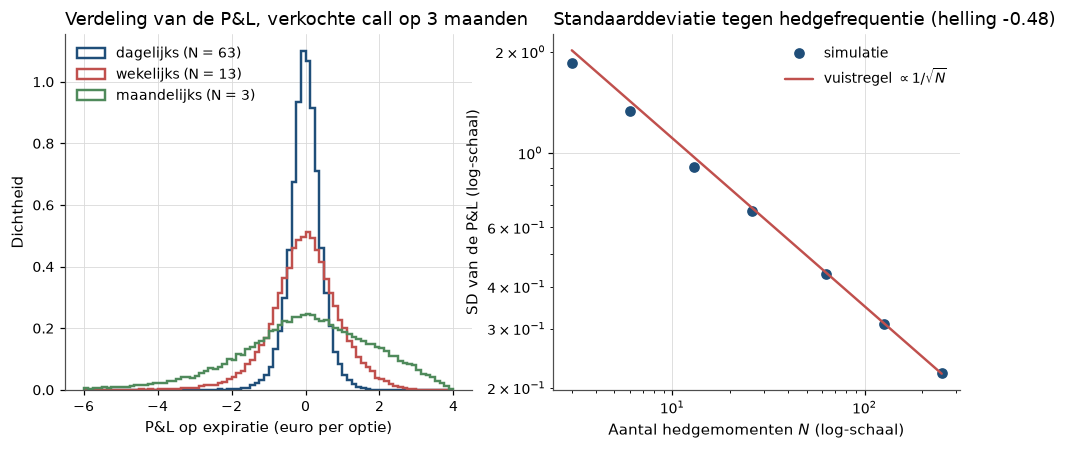

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
bins = np.linspace(-6, 4, 81)
for i, (name, pnl) in enumerate(pnl_by_freq.items()):
    axes[0].hist(pnl, bins=bins, density=True, histtype="step", lw=1.6,
                 color=hap.plotting.COLORS[i], label=f"{name} (N = {frequencies[name]})")
axes[0].set_title("Verdeling van de P&L, verkochte call op 3 maanden")
axes[0].set_xlabel("P&L op expiratie (euro per optie)")
axes[0].set_ylabel("Dichtheid")
axes[0].legend()

axes[1].loglog(n_grid, sd_grid, "o", color=hap.plotting.COLORS[0], label="simulatie")
axes[1].loglog(n_grid, np.sqrt(np.pi / 4) * vega_sim * sigma_sim / np.sqrt(n_grid),
               color=hap.plotting.COLORS[1], label=r"vuistregel $\propto 1/\sqrt{N}$")
axes[1].set_title(f"Standaarddeviatie tegen hedgefrequentie (helling {slope_sd:.2f})")
axes[1].set_xlabel("Aantal hedgemomenten $N$ (log-schaal)")
axes[1].set_ylabel("SD van de P&L (log-schaal)")
axes[1].legend()
plt.show()

:::{figure} #cel-black-scholes-hedgefout
:label: fig-black-scholes-hedgefout
:width: 95%

Links: de P&L is bij elke frequentie gemiddeld vrijwel nul, maar bij maandelijks
hedgen is haar spreiding ruim veertig procent van de premie. Rechts: over bijna twee
decaden in $N$ volgt de spreiding de $1/\sqrt{N}$-wet. De drift van 10% per jaar
verschuift de verdelingen niet zichtbaar.
:::

Zoals $p$ in de boom, doet $\mu$ er in de simulatie vrijwel niet toe.

Hier komt de standaardfout van 2% uit [](#00-01-rendementen) terug: bij 20%
volatiliteit ligt een gemiddeld rendement na een eeuw data maar op twee
procentpunt nauwkeurig vast. Voor volatiliteit ligt dat anders. Een handelaar verkoopt tien jaar lang elke maand één optie, telkens één
volatiliteitspunt te duur. Per optie verwacht hij de vega maal $0{,}01$, dus
$0{,}20$ euro. Hedget hij dagelijks, dan is de standaardfout van zijn gemiddelde na
120 opties $0{,}43/\sqrt{120} = 0{,}04$, en is zijn voordeel met $t \approx 5$
zichtbaar. Hedget hij maandelijks, dan is die standaardfout $1{,}86/\sqrt{120} =
0{,}17$, en is het voordeel na tien jaar niet van ruis te onderscheiden. Een
voordeel in volatiliteit is dus meetbaar op een manier waarop een voordeel in
gemiddeld rendement dat bijna nooit is. Er zijn twee voorbehouden: wie weinig
hedget, verliest het voordeel in de spreiding van de P&L, en in deze simulatie is
$\sigma$ constant, terwijl ze in werkelijkheid zelf onzeker is.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Mark Rubinstein, *Implied Binomial Trees*, Journal of Finance 1994
{cite}`Rubinstein1994`. Emanuel Derman en Iraj Kani, *The Volatility Smile and Its
Implied Tree*, 1994 {cite}`DermanKani1994`.

**Wat.** De *smirk*: sinds de crash van 1987 is de implied volatility van
S&P 500-indexopties hoger naarmate de uitoefenprijs lager is
{cite}`ConstantinidesJackwerthPerrakis2008`. Derman en Kani beschrijven hetzelfde
patroon voor opties uit 1994.

**Data hier.** Een momentopname van de SPY-optieketen met 28 expiraties via
`hap.data.yahoo_options`, de rente uit FRED en de termijnkoers per expiratie uit de
pariteit.

**Verschil met het origineel.** Rubinstein had Europese indexopties rond de crash.
Wij hebben één dag, bijna veertig jaar later, en Amerikaanse opties op een ETF met
dividend. De periode vóór 1987 is met gratis data niet te repliceren.

**Verwachte afwijking.** Alleen teken en vorm zijn te toetsen, want de niveaus
hangen van de dag af en de getallen van de bronnen zijn niet tegen de bron te houden.
Tot één jaar ligt de implied volatility op 90% van de termijnkoers boven die op de
termijnkoers, het steilst bij de kortste looptijden.
```

We laden de keten, halen per expiratie de termijnkoers uit de pariteit, en rekenen
voor elke *out-of-the-money* optie (een put onder of een call boven de
termijnkoers) de implied volatility uit. Bij die opties is de premie voor vroege
uitoefening van Amerikaanse opties het kleinst. Als onderliggende waarde nemen we de
verdisconteerde termijnkoers, zoals in de variant van Black voor termijncontracten
{cite}`Black1976`. Zo vraagt het dividend geen aanname.

In [11]:
chain = hap_data.yahoo_options("SPY", 28)
spot = float(chain["spot"].iloc[0])
valuation = pd.Timestamp(chain.index.max().date()) + pd.Timedelta(hours=16)
r_cc = np.log1p(hap_data.fred("DGS3MO")["DGS3MO"].dropna().loc[:valuation].iloc[-1] / 100)

quotes = chain.reset_index()
quotes = quotes[(quotes["bid"] > 0) & (quotes["ask"] > quotes["bid"])].copy()
quotes["mid"] = 0.5 * (quotes["bid"] + quotes["ask"])
quotes["T"] = ((quotes["expiry"] + pd.Timedelta(hours=16) - valuation).dt.total_seconds()
               / (365.25 * 86400))
quotes = quotes[quotes["T"] > 2 / 365]
quotes["DF"] = np.exp(-r_cc * quotes["T"])


def parity_forward(group):
    """Median forward from put-call parity over strikes within 5% of spot."""
    wide = group.pivot_table(index="strike", columns="kind", values="mid").dropna()
    wide = wide[np.abs(np.log(wide.index / spot)) < 0.05]
    return float(np.median(wide.index + (wide["call"] - wide["put"]) / group["DF"].iloc[0]))


forwards = quotes.groupby("expiry").apply(parity_forward, include_groups=False).rename("F")
quotes = quotes.join(forwards, on="expiry")
forward_table = pd.DataFrame({"F": forwards, "F / spot - 1": forwards / spot - 1})
forward_table.index = forward_table.index.date
forward_table.iloc[[0, 9, 18, 27]].round(4)

,F,F / spot - 1
2026-09-14,764.4286,0.0002
2026-10-16,765.3760,0.0014
2027-02-26,775.3660,0.0145
2028-12-15,830.5591,0.0867


De termijnkoers ligt bij korte looptijden vrijwel op de spot en ligt bij ruim twee
jaar bijna 9% hoger: rente min dividend over die looptijd. Nu selecteren we de out-of-the-money opties
en rekenen hun implied volatility uit.

In [12]:
otm = quotes[((quotes["kind"] == "put") & (quotes["strike"] < quotes["F"]))
             | ((quotes["kind"] == "call") & (quotes["strike"] >= quotes["F"]))].copy()
otm = otm[otm["mid"] >= 0.05]
otm["k"] = np.log(otm["strike"] / otm["F"])
# Black (1976): discounted forward as the underlying, so no dividend assumption is needed
otm["iv"] = implied_vol(otm["mid"].to_numpy(), (otm["DF"] * otm["F"]).to_numpy(),
                        otm["strike"].to_numpy(), otm["T"].to_numpy(), r_cc, otm["kind"].to_numpy())
otm = otm.dropna(subset=["iv"])
pd.Series({"waarderingsmoment": str(valuation), "spot": round(spot, 2), "r (continu)": round(r_cc, 4),
           "OTM-opties": len(otm), "expiraties": otm["expiry"].nunique()})

waarderingsmoment    2026-09-11 16:00:00
spot                              764.29
r (continu)                       0.0382
OTM-opties                          4521
expiraties                            28
dtype: object

De momentopname is van 11 september 2026 en levert 4521 bruikbare opties over 28
expiraties. We meten de uitoefenprijs als *log-moneyness* $k = \log(K/F)$, de
procentuele afstand tot de termijnkoers: 90% van de termijnkoers is
$k = \log 0{,}9 \approx -0{,}105$. De tabel hieronder geeft per expiratie de implied
volatility bij 90%, 95%, 100% en 105% van de termijnkoers.

In [13]:
def iv_at(group, k):
    """Linearly interpolated implied vol at log-moneyness k (NaN outside the quoted range)."""
    g = group.sort_values("k")
    return float(np.interp(k, g["k"], g["iv"])) if g["k"].min() <= k <= g["k"].max() else np.nan


smile_table = pd.DataFrame(
    {
        expiry: {
            "T (jaar)": g["T"].iloc[0],
            "F / spot - 1": g["F"].iloc[0] / spot - 1,
            "IV 90%": iv_at(g, np.log(0.90)),
            "IV 95%": iv_at(g, np.log(0.95)),
            "IV ATM": iv_at(g, 0.0),
            "IV 105%": iv_at(g, np.log(1.05)),
        }
        for expiry, g in otm.groupby("expiry")
    }
).T
smile_table["skew 90%-ATM"] = smile_table["IV 90%"] - smile_table["IV ATM"]
smile_table.index = smile_table.index.date
within_year = smile_table[smile_table["T (jaar)"] <= 1.0].dropna(subset=["skew 90%-ATM"])
smile_table.round(4)

,T (jaar),F / spot - 1,IV 90%,IV 95%,IV ATM,IV 105%,skew 90%-ATM
2026-09-14,0.0082,0.0002,NaN,0.2429,0.0708,NaN,NaN
2026-09-15,0.0110,0.0003,NaN,0.2271,0.0844,NaN,NaN
2026-09-16,0.0137,0.0003,NaN,0.2237,0.1076,NaN,NaN
2026-09-17,0.0164,0.0004,NaN,0.2206,0.1159,NaN,NaN
2026-09-18,0.0192,-0.0011,0.3420,0.2179,0.1261,NaN,0.2160
2026-09-25,0.0383,-0.0010,0.2709,0.1864,0.1183,0.1077,0.1525
2026-09-30,0.0520,-0.0006,0.2498,0.1794,0.1180,0.1002,0.1318
2026-10-02,0.0575,-0.0002,0.2482,0.1808,0.1222,0.1007,0.1260
2026-10-09,0.0767,0.0007,0.2359,0.1765,0.1243,0.1007,0.1115
2026-10-16,0.0958,0.0014,0.2290,0.1753,0.1276,0.1038,0.1014


Black-Scholes voorspelt één getal per rij, maar elke rij daalt van links naar rechts. De
vier kortste expiraties hebben geen put op 90%. Hun at-the-money-volatiliteit is
onbetrouwbaar laag (7 tot 12%), omdat we de looptijd in kalenderdagen tellen en er
een weekend in zit. De tabel hieronder zet de helling op drie looptijden naast de
verwachting uit het replicatieblok.

In [14]:
def skew_near(years):
    """Skew IV(90%) - IV(ATM) at the expiry closest to the given maturity."""
    return smile_table["skew 90%-ATM"].iloc[np.argmin(np.abs(smile_table["T (jaar)"] - years))]


pd.DataFrame(
    {
        "verwacht": ["> 0, grootst", "> 0", "> 0, kleinst", "alle", ""],
        "hier": [skew_near(7 / 365.25), skew_near(49 / 365.25), skew_near(1.0),
                 (within_year["skew 90%-ATM"] > 0).sum(), len(within_year)],
    },
    index=["helling 90%-ATM, een week", "helling 90%-ATM, zeven weken",
           "helling 90%-ATM, een jaar", "expiraties tot 1 jaar met helling > 0",
           "expiraties tot 1 jaar met een put op 90%"],
).round(4)

,verwacht,hier
"helling 90%-ATM, een week","> 0, grootst",0.2160
"helling 90%-ATM, zeven weken",> 0,0.0873
"helling 90%-ATM, een jaar","> 0, kleinst",0.0289
expiraties tot 1 jaar met helling > 0,alle,19.0000
expiraties tot 1 jaar met een put op 90%,,19.0000


**Geslaagd.** Het teken is zoals het replicatieblok verwachtte: bij alle negentien
expiraties tot een jaar ligt de implied volatility op 90% boven die op de
termijnkoers. De helling daalt met de looptijd, van 21 volatiliteitspunten bij een
week via 9 bij zeven weken naar 3 bij een jaar.

De figuur toont vijf looptijden en het hele oppervlak. Let erop dat geen enkele
kromme horizontaal loopt.

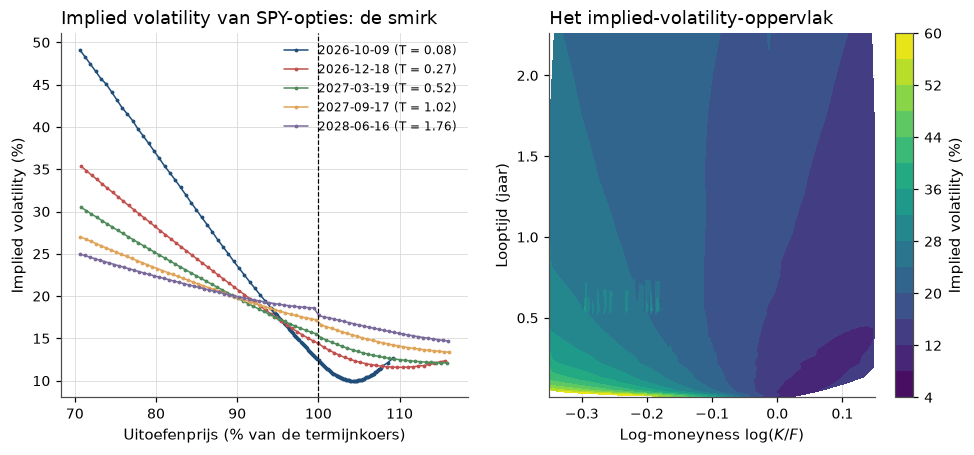

In [15]:
targets = [1 / 12, 0.25, 0.5, 1.0, 2.0]
expiry_T = otm.groupby("expiry")["T"].first()
chosen = [expiry_T.index[np.argmin(np.abs(expiry_T.to_numpy() - t))] for t in targets]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for i, expiry in enumerate(chosen):
    g = otm[(otm["expiry"] == expiry) & (otm["k"].between(-0.35, 0.15))].sort_values("k")
    axes[0].plot(np.exp(g["k"]) * 100, g["iv"] * 100, ".-", ms=3, lw=1.0,
                 color=hap.plotting.COLORS[i], label=f"{expiry.date()} (T = {g['T'].iloc[0]:.2f})")
axes[0].axvline(100, color="black", lw=0.8, ls="--")
axes[0].set_title("Implied volatility van SPY-opties: de smirk")
axes[0].set_xlabel("Uitoefenprijs (% van de termijnkoers)")
axes[0].set_ylabel("Implied volatility (%)")
axes[0].legend(fontsize=8)

surface = otm[otm["k"].between(-0.35, 0.15) & (otm["T"] <= 2.5)]
contour = axes[1].tricontourf(surface["k"], surface["T"], surface["iv"] * 100, levels=14, cmap="viridis")
fig.colorbar(contour, ax=axes[1], label="Implied volatility (%)")
axes[1].set_title("Het implied-volatility-oppervlak")
axes[1].set_xlabel(r"Log-moneyness $\log(K/F)$")
axes[1].set_ylabel("Looptijd (jaar)")
plt.show()

:::{figure} #cel-black-scholes-smirk
:label: fig-black-scholes-smirk
:width: 95%

Links: onder Black-Scholes zou elke kromme een horizontale lijn op dezelfde hoogte
zijn. Van diepe puts naar de termijnkoers dalen alle krommen, het steilst bij de
kortste looptijd: puts ver onder de termijnkoers zijn duur in volatiliteitstermen. Rechts: hetzelfde als oppervlak. De
helling in de uitoefenprijs is overal aanwezig en vlakt af met de looptijd.
:::

De tweede replicatie vraagt wat een gehedgde verkoper van opties gemiddeld verdient.
Volgens [](#eq-black-scholes-hedge-pnl) is dat het verschil tussen ingeprijsde en
gerealiseerde variantie.

```{admonition} Replicatie
:class: seealso

**Bron.** Robert Whaley, *The Investor Fear Gauge*, Journal of Portfolio Management
2000 {cite}`Whaley2000`. Peter Carr en Liuren Wu, *Variance Risk Premiums*, Review
of Financial Studies 2009 {cite}`CarrWu2009`.

**Wat.** Het teken van de *variance risk premium* (ingeprijsde min daarna
gerealiseerde variantie). Hun getallen zijn niet tegen de bron te houden, dus we
toetsen teken en vorm.

**Data hier.** De VIX uit FRED vanaf 1990, en de dagelijkse marktfactor van Kenneth
French, waaruit we per dag de gerealiseerde volatiliteit over de volgende 21
handelsdagen berekenen.

**Verschil met het origineel.** De VIX meet de verwachte volatiliteit van de S&P 500
over dertig kalenderdagen. Wij vergelijken met de hele Amerikaanse markt over 21
handelsdagen. Dertig kalenderdagen zijn ongeveer 21 handelsdagen.

**Verwachte afwijking.** Het verschil moet gemiddeld
positief zijn, met een Newey-West-$t$-waarde ruim boven twee, positief op een ruime
meerderheid van de dagen, en omslaan in crisismaanden zoals eind 2008 en begin 2020.
```

We berekenen het verschil per dag en schatten het gemiddelde. Opeenvolgende dagen
delen 20 van de 21 dagen gerealiseerde volatiliteit, dus de verschillen hangen sterk
samen en een gewone standaardfout is te klein. De Newey-West-standaardfout corrigeert
daarvoor. We nemen 42 vertragingen, twee keer de lengte van het venster van 21
dagen.

In [16]:
vix = (hap_data.fred("VIXCLS")["VIXCLS"].dropna() / 100).rename("VIX")
log_mkt = np.log1p(hap_data.market_daily()["Mkt"])
realized_fwd = np.sqrt(252 * log_mkt.pow(2).rolling(21).mean().shift(-21)).rename("RV volgende 21 dagen")

vrp = vix.to_frame().join(realized_fwd, how="inner").dropna()
vrp["verschil"] = vrp["VIX"] - vrp["RV volgende 21 dagen"]
nw = hap.newey_west(vrp["verschil"], pd.Series(1.0, index=vrp.index, name="const"),
                    lags=42, add_constant=False)
monthly_vrp = vrp.resample("ME").last()
worst_months = ", ".join(f"{d:%Y-%m}" for d in monthly_vrp["verschil"].nsmallest(4).index)

De tabel zet de uitkomst naast de verwachting uit het replicatieblok.

In [17]:
pd.DataFrame(
    {
        "verwacht": ["", "", "", "", "> 0", "", "> 2", "meerderheid", "> 0", "2008, 2020"],
        "hier": [
            f"{vrp.index[0]:%Y-%m-%d} t/m {vrp.index[-1]:%Y-%m-%d}", len(vrp),
            round(vrp["VIX"].mean(), 4), round(vrp["RV volgende 21 dagen"].mean(), 4),
            round(vrp["verschil"].mean(), 4), round(float(nw.bse.iloc[0]), 4),
            round(float(nw.tvalues.iloc[0]), 4), round((vrp["verschil"] > 0).mean(), 4),
            round((vrp["VIX"] ** 2 - vrp["RV volgende 21 dagen"] ** 2).mean(), 4), worst_months,
        ],
    },
    index=["periode", "handelsdagen", "gemiddelde VIX", "gemiddelde RV",
           "gemiddeld verschil (vol)", "Newey-West SE", "Newey-West t",
           "fractie dagen VIX > RV", "gemiddeld verschil (variantie)",
           "meest negatieve maandeinden"],
)

,verwacht,hier
periode,,1990-01-02 t/m 2026-07-01
handelsdagen,,9188
gemiddelde VIX,,0.1945
gemiddelde RV,,0.1546
gemiddeld verschil (vol),> 0,0.0399
Newey-West SE,,0.0031
Newey-West t,> 2,12.805
fractie dagen VIX > RV,meerderheid,0.85
gemiddeld verschil (variantie),> 0,0.011
meest negatieve maandeinden,"2008, 2020","2020-02, 2008-09, 2008-08, 2025-03"


**Geslaagd.** Elke verwachting uit het replicatieblok komt uit: de VIX ligt
gemiddeld ruim boven de daarna gerealiseerde volatiliteit, met een $t$-waarde ver
boven twee, op de meeste dagen, en het verschil slaat om in 2008 en 2020. De
figuur laat zien waar het omslaat.

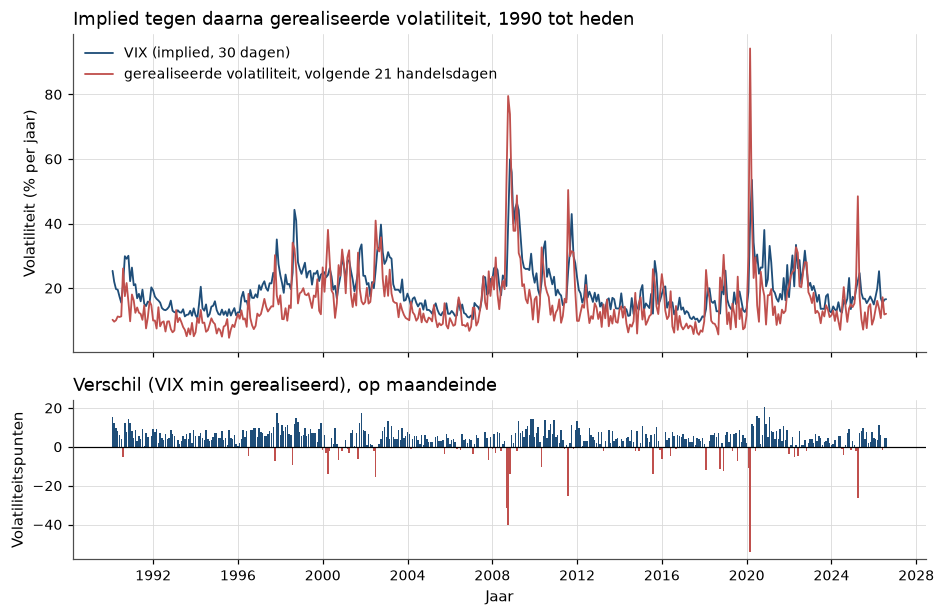

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True, height_ratios=[2, 1])
axes[0].plot(monthly_vrp.index, monthly_vrp["VIX"] * 100, lw=1.2, label="VIX (implied, 30 dagen)")
axes[0].plot(monthly_vrp.index, monthly_vrp["RV volgende 21 dagen"] * 100, lw=1.2,
             label="gerealiseerde volatiliteit, volgende 21 handelsdagen")
axes[0].set_title("Implied tegen daarna gerealiseerde volatiliteit, 1990 tot heden")
axes[0].set_ylabel("Volatiliteit (% per jaar)")
axes[0].legend()
axes[1].bar(monthly_vrp.index, monthly_vrp["verschil"] * 100, width=25,
            color=np.where(monthly_vrp["verschil"] > 0, hap.plotting.COLORS[0], hap.plotting.COLORS[1]))
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Verschil (VIX min gerealiseerd), op maandeinde")
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("Volatiliteitspunten")
plt.show()

:::{figure} #cel-black-scholes-vrp
:label: fig-black-scholes-vrp
:width: 95%

De VIX ligt meestal boven de volatiliteit die daarna optreedt. Opties zijn in die zin
gemiddeld duur. De negatieve staven zijn zeldzaam maar groot: wie opties verkoopt,
verdient in de meeste maanden een beetje en verliest in enkele maanden veel.
:::

De meest negatieve maandeinden zijn februari 2020, september en augustus 2008 en
maart 2025. Met $t = 12{,}8$ bevestigen de data wat de simulatie voor een voordeel in
volatiliteit liet zien: een premie op tweede momenten is scherp te meten.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Het gaf de eerste prijs zonder voorkeuren. Uit één
argument, dat wat zonder risico is de rente verdient, volgt een formule met vier
waarneembare invoergrootheden en één te schatten getal. Binnen enkele jaren
gebruikten de handelaren op de nieuwe beurs de formule. Het model verklaart waarom het verwachte
rendement er niet toe doet, en waarom een optie meer waard is als het aandeel wilder
beweegt. De simulatie liet zien hoe robuust de kern is: de drift laat vrijwel geen
spoor na, en de spreiding van de P&L volgt de $1/\sqrt{N}$-wet.

**Waar het breekt.** Het model voorspelt één volatiliteit per aandeel, de markt
geeft er een per uitoefenprijs en looptijd. Op onze handelsdag lag de implied
volatility op 90% van de termijnkoers bij alle negentien expiraties tot een jaar
boven die op de termijnkoers. Het verschil liep van 21 volatiliteitspunten bij een
week tot 3 bij een jaar. Implied volatility wordt zo een oppervlak. Dure diepe puts betekenen dat de
risiconeutrale verdeling een grote daling waarschijnlijker maakt dan de lognormale:
een dikkere linkerstaart. Dit
is geen schattingsprobleem, want tweede momenten zijn goed meetbaar.

**Risico of vergissing?** De Chicago-lezing (de prijs is juist en beloont risico): koersen maken sprongen, en de
volatiliteit stijgt als koersen dalen. Een diepe put verzekert dan tegen de
toestanden waarin een euro het meest waard is. Zo'n sprong is niet weg te hedgen, en
wie het risico draagt, eist een premie. De Yale-lezing (de prijs zit ernaast): sinds 1987 is er structurele
vraag naar bescherming, terwijl verkopers van puts beperkt kapitaal hebben. Dan ligt
de prijs boven wat het risico rechtvaardigt. Constantinides, Jackwerth en Perrakis
vonden na de crash strategieën die elke risicomijdende belegger zou verkiezen, en
lezen dat als mispricing {cite}`ConstantinidesJackwerthPerrakis2008`. Scheiden vraagt
de *stochastic discount factor* (hoe zwaar een euro in elke toestand weegt) in
crashtoestanden, en die komen in een eeuw data te
weinig voor. De data van deze lecture kiezen niet.

**Wat er daarna kwam.** Merton had dezelfde wiskunde in continue tijd al vanaf
1969 gebruikt voor de portefeuillekeuze van beleggers. In 1973 leidde hij er het
evenwicht van de hele markt mee af: zie [](#03-10-merton-icapm).

## Oefeningen

:::{exercise}
:label: ex-black-scholes-1

**Instap: de boom gevarieerd.** Neem het toy-voorbeeld met $K = 110$.

1. Bereken $C_0$ met de hand, met de risiconeutrale kans $q$.
2. Maak de boom fijner, zoals Cox, Ross en Rubinstein {cite}`CoxRossRubinstein1979`:
   $n$ stappen over $T = 0{,}25$, met $u = e^{\sigma\sqrt{T/n}}$,
   $d = 1/u$ en $R^{f} = e^{rT/n}$, bij $S = K = 100$, $r = 4\%$ en $\sigma = 20\%$.
   Teken het verschil met [](#eq-black-scholes-call) voor $n = 1, \dots, 200$.
:::

:::{solution} ex-black-scholes-1
:class: dropdown

**(1)** Alleen drie stijgingen eindigen boven 110, met payoff $23{,}1$. Dus
$C_0 = 0{,}216 \cdot 23{,}1/1{,}061208 = 4{,}7018$.

**(2)** De code rekent (1) na en tekent de convergentie.

C_0 bij K = 110: 4.7018


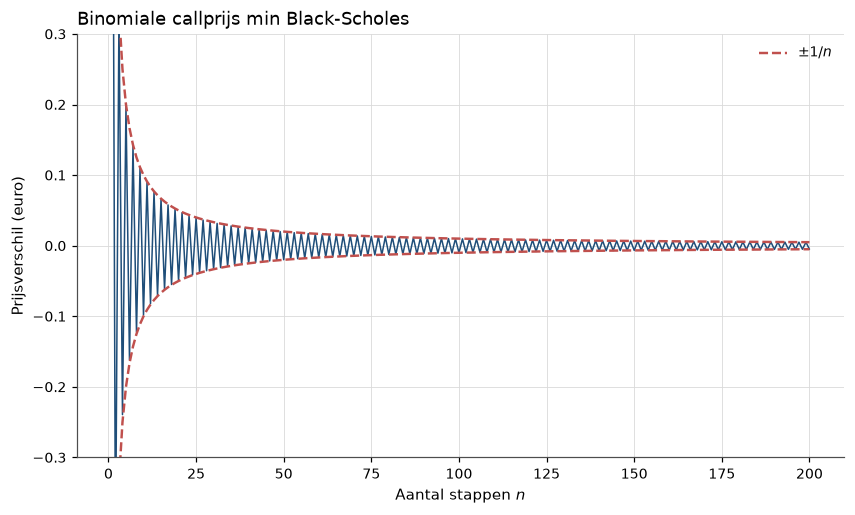

fout bij n = 3: 0.3328; n = 50: -0.0199; n = 200: -0.00498


In [19]:
payoff_110 = np.maximum(toy["S0"] * toy["u"] ** up_moves * toy["d"] ** (toy["n"] - up_moves) - 110.0, 0.0)
price_110 = stats.binom.pmf(up_moves, toy["n"], q_toy) @ payoff_110 / toy["R_f"] ** toy["n"]
print(f"C_0 bij K = 110: {price_110:.4f}")


def crr_call(S, K, T, r, sigma, n):
    """Cox-Ross-Rubinstein binomial price of a European call."""
    dt = T / n
    up = np.exp(sigma * np.sqrt(dt))
    q = (np.exp(r * dt) - 1 / up) / (up - 1 / up)
    j = np.arange(n + 1)
    terminal = np.maximum(S * up ** (2 * j - n) - K, 0.0)
    return np.exp(-r * T) * stats.binom.pmf(j, n, q) @ terminal


n_steps = np.arange(1, 201)
bs_exact = bs_price(100.0, 100.0, 0.25, 0.04, 0.20)
errors = np.array([crr_call(100.0, 100.0, 0.25, 0.04, 0.20, k) - bs_exact for k in n_steps])

fig, ax = plt.subplots()
ax.plot(n_steps, errors, lw=1.0)
ax.plot(n_steps, 1.0 / n_steps, color=hap.plotting.COLORS[1], ls="--", label=r"$\pm 1/n$")
ax.plot(n_steps, -1.0 / n_steps, color=hap.plotting.COLORS[1], ls="--")
ax.set_ylim(-0.3, 0.3)
ax.set_title("Binomiale callprijs min Black-Scholes")
ax.set_xlabel("Aantal stappen $n$")
ax.set_ylabel("Prijsverschil (euro)")
ax.legend()
plt.show()
print(f"fout bij n = 3: {errors[2]:.4f}; n = 50: {errors[49]:.4f}; n = 200: {errors[199]:.5f}")

De fout blijft binnen de stippellijnen $\pm 1/n$: ze daalt ongeveer als $1/n$ en
wisselt van teken, omdat de uitoefenprijs
afwisselend op en tussen eindknopen valt: $0{,}33$ bij drie stappen, een halve cent
bij tweehonderd. Wat dit leert: de boom en de formule zijn hetzelfde idee,
replicatie per knoop, en de formule is de limiet van de boom.
:::

:::{exercise}
:label: ex-black-scholes-2

**Afleiding: verkopen tegen de verkeerde volatiliteit.**

1. Toon met [](#eq-black-scholes-pariteit) aan dat gamma en vega van call en put
   gelijk zijn.
2. Het aandeel beweegt met 20%. Een handelaar verkoopt de call op drie maanden uit
   de simulatie tegen 15% of 25%, en hedget dagelijks met die implied volatility of
   met de werkelijke 20%. Voorspel met [](#eq-black-scholes-hedge-pnl) de gemiddelde
   P&L en welke hedge de kleinste spreiding geeft. Controleer met een simulatie.
:::

:::{solution} ex-black-scholes-2
:class: dropdown

**(1)** $P = C - S + Ke^{-r\tau}$, en $-S + Ke^{-r\tau}$ is lineair in $S$ en hangt
niet van $\sigma$ af. De tweede afgeleide naar $S$ en de afgeleide naar $\sigma$
zijn dus gelijk. Zonder rekenen: call min put is een termijncontract.

**(2)** De gemiddelde P&L is ongeveer $\nu(\sigma_i - \sigma_g) = \pm 0{,}99$.
Wie met de werkelijke volatiliteit hedget, legt het premieverschil vast. Alleen de spreiding
door discreet hedgen blijft over. Wie met $\sigma_i$ hedget, heeft daarnaast de padafhankelijke
term uit de propositie.

In [20]:
wrong_rows = []
for sigma_i in (0.15, 0.25):
    premium_gap = (bs_price(100.0, 100.0, T_sim, r_sim, sigma_i)
                   - bs_price(100.0, 100.0, T_sim, r_sim, sigma_sim)) * np.exp(r_sim * T_sim)
    for label, sigma_h in (("hedge bij implied", sigma_i), ("hedge bij werkelijke", sigma_sim)):
        pnl = delta_hedge_pnl(63, n_paths, 100.0, 100.0, T_sim, r_sim, mu_sim,
                              sigma_sim, sigma_i, sigma_hedge=sigma_h)
        wrong_rows.append({"sigma_i": sigma_i, "hedge": label, "gemiddelde P&L": pnl.mean(),
                           "SD P&L": pnl.std(ddof=1), "premieverschil": premium_gap,
                           "vega x (sigma_i - sigma_g)": vega_sim * (sigma_i - sigma_sim)})
pd.DataFrame(wrong_rows).set_index(["sigma_i", "hedge"]).round(4)

gemiddelde P&L  SD P&L  premieverschil  \
sigma_i hedge                                                          
0.15    hedge bij implied            -0.9838  0.6096         -0.9947   
        hedge bij werkelijke         -0.9955  0.4320         -0.9947   
0.25    hedge bij implied             0.9960  0.5478          0.9968   
        hedge bij werkelijke          0.9960  0.4297          0.9968   

                              vega x (sigma_i - sigma_g)  
sigma_i hedge                                             
0.15    hedge bij implied                        -0.9862  
        hedge bij werkelijke                     -0.9862  
0.25    hedge bij implied                         0.9862  
        hedge bij werkelijke                      0.9862

Wie tegen 15% verkoopt, verliest gemiddeld $0{,}98$ à $1{,}00$ euro. Wie tegen 25%
verkoopt, wint $1{,}00$. Met de werkelijke volatiliteit is de spreiding $0{,}43$, net
als in de simulatie. Met de implied volatility is ze $0{,}61$ en $0{,}55$. Wat dit
leert: een gehedgde optie is een weddenschap op gerealiseerde variantie, en wie met
de eigen $\sigma_i$ hedget, laat de uitkomst afhangen van waar de koers zich ophoudt.
:::

:::{exercise}
:label: ex-black-scholes-3

**Is de variance risk premium stabiel?** Splits de steekproef in 1990–2007 en
2008–heden. Bereken per periode het gemiddelde verschil tussen VIX en gerealiseerde
volatiliteit met een Newey-West-standaardfout. Bereken met niet-overlappende
maanddata het aantal jaren $T^{*} = (1{,}96\,\SD/\text{gemiddelde})^2$ dat nodig is
voor significantie. Vergelijk met een equity premium van 6% bij 20% volatiliteit.
:::

:::{solution} ex-black-scholes-3
:class: dropdown

In [21]:
periods = {"1990-2007": vrp.loc[:"2007"], "2008-heden": vrp.loc["2008":]}
rows = []
for name, sample in periods.items():
    fit = hap.newey_west(sample["verschil"], pd.Series(1.0, index=sample.index, name="const"),
                         lags=42, add_constant=False)
    monthly = sample["verschil"].resample("ME").last().dropna()
    rows.append({
        "periode": name,
        "gemiddeld verschil": sample["verschil"].mean(),
        "NW SE": float(fit.bse.iloc[0]),
        "NW t": float(fit.tvalues.iloc[0]),
        "maanden": len(monthly),
        "jaren nodig (maanddata)": (1.96 * monthly.std(ddof=1) / monthly.mean()) ** 2 / 12,
    })
equity_years = (1.96 * 0.20 / 0.06) ** 2
print(f"jaren nodig voor een equity premium van 6% bij sigma = 20%: {equity_years:.1f}")
pd.DataFrame(rows).set_index("periode").round(4)

jaren nodig voor een equity premium van 6% bij sigma = 20%: 42.7


,gemiddeld verschil,NW SE,NW t,maanden,jaren nodig (maanddata)
periode,,,,,
1990-2007,0.0485,0.0032,15.0269,216,0.3297
2008-heden,0.0315,0.0052,6.1048,223,2.0260


Het verschil is in beide periodes positief en scherp gemeten: $4{,}85$ punten over
1990–2007 ($t = 15{,}0$) en $3{,}15$ punten vanaf 2008 ($t = 6{,}1$). Voor
significantie is met maanddata een derde van een jaar nodig (1990–2007) en twee
jaar (vanaf 2008). Voor de equity
premium is dat 43 jaar. De kleinere premie na 2008 past bij beide lezingen: arbitrageurs
die een bekende vergissing wegnemen, of een crashrisico dat blijft en dus beloond
blijft. Wat dit leert: de standaardfout van 2% treft het gemiddelde rendement, niet
een premie op tweede momenten.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->